# 📊 Notebook 01 — Data Understanding

**Project:** AI-Powered Demand Forecasting & Inventory Optimization  
**Author:** NTI Capstone Team  
**Environment:** Local / Google Colab

---

## 🎯 Purpose

Build a **complete inventory** of all datasets: shapes, types, missing values,  
distributions, and timeline coverage — before any analysis or modeling begins.

| Item | Detail |
|------|--------|
| **Inputs** | 7 Parquet files from `01_Dataset/parquet/` |
| **Outputs** | Summary tables + figures saved to `output/01_data_understanding/` |
| **Next** | `02_eda.ipynb` |

---


## 1️⃣ Project Bootstrap


In [1]:
# ============================================================
# Project Bootstrap (Google Colab + Local)
# Run this cell first in every notebook.
# ============================================================
import os, sys
from pathlib import Path

# 1. Mount Google Drive (Colab only)
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

# 2. Find project root (checks Drive paths + local paths)
POSSIBLE_ROOTS = [
    # Google Drive paths
    Path('/content/drive/MyDrive/Demand-Forecasting-System'),
    Path('/content/drive/MyDrive/NTI/Demand-Forecasting-System'),
    Path('/content/drive/MyDrive/Colab Notebooks/Demand-Forecasting-System'),
    # Local paths (for VS Code / Jupyter)
    Path.cwd(),
    Path.cwd().parent,
]

PROJECT_ROOT = None
for p in POSSIBLE_ROOTS:
    if p.exists() and (p / 'config.py').exists():
        PROJECT_ROOT = p.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        '❌ Project root with config.py not found.\n'
        'Colab: Make sure the folder is in your Google Drive (MyDrive/Demand-Forecasting-System).\n'
        'Shared with me? Right-click → Organize → Add shortcut to My Drive.\n'
        'Local: Run the notebook from inside the project directory.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

ENV = 'Google Colab' if 'google.colab' in sys.modules else 'Local'
print('=' * 60)
print(f'📁 Project Root : {PROJECT_ROOT}')
print(f'📂 Working Dir  : {os.getcwd()}')
print(f'🖥️  Runtime      : {ENV}')
print('✅ Bootstrap OK')
print('=' * 60)


📁 Project Root : F:\NTI\Demand Forecasting System Backup
📂 Working Dir  : F:\NTI\Demand Forecasting System Backup
🖥️  Runtime      : Local
✅ Bootstrap OK


## 2️⃣ Imports & Configuration

Set up libraries, display settings, output directory, and helper functions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import config, utils

# ── Display & Plot Settings ──
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.sans-serif': 'Segoe UI'})

# ── Output directory ──
from pathlib import Path
OUTPUT_DIR = Path(config.PROJECT_ROOT) / 'output' / '01_data_understanding'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'📂 Figures will be saved to: {OUTPUT_DIR}')


📂 Figures will be saved to: F:\NTI\Demand Forecasting System Backup\output\01_data_understanding


In [16]:
from IPython.display import HTML
import matplotlib.pyplot as plt

# ============================================================
# Premium KPI Card
# ============================================================
def kpi(title, value, subtitle="", color="#3B82F6"):
    return HTML(f"""
    <div style="
        background: linear-gradient(135deg,#1e1e2f,#2b2b40);
        border-left:7px solid {color};
        border-radius:16px;
        padding:22px;
        margin:10px 6px;
        display:inline-block;
        min-width:280px;
        box-shadow:0 8px 20px rgba(0,0,0,.35);
        font-family:'Segoe UI',sans-serif;
        transition:.3s;
    ">

        <div style="
            color:#D1D5DB;
            font-size:13px;
            font-weight:600;
            text-transform:uppercase;
            letter-spacing:1px;
        ">
            {title}
        </div>

        <div style="
            color:{color};
            font-size:38px;
            font-weight:800;
            margin:10px 0 6px 0;
            line-height:1;
        ">
            {value}
        </div>

        <div style="
            color:#9CA3AF;
            font-size:14px;
        ">
            {subtitle}
        </div>

    </div>
    """)


# ============================================================
# Save & Show Figure
# ============================================================
def save_fig(fig, filename):
    """
    Save high-quality figure then display it.
    """
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / filename,
        dpi=300,
        bbox_inches="tight",
        facecolor="#ffffff",
        edgecolor="none"
    )

    print(f"💾 Figure saved → {OUTPUT_DIR / filename}")

    plt.show()

## 3️⃣ Load All Datasets

Load all **7 Parquet datasets** into memory using the centralized `utils.load_all_parquet()` loader.

| File | Variable | Description |
|------|----------|-------------|
| `train.parquet` | `df_train` | ~125M sales records (2013–2017) |
| `test.parquet` | `df_test` | Prediction period |
| `stores.parquet` | `df_stores` | 54 store profiles |
| `items.parquet` | `df_items` | 4,100 product items |
| `oil.parquet` | `df_oil` | Daily WTI oil prices |
| `transactions.parquet` | `df_trans` | Daily transaction counts |
| `holidays_events.parquet` | `df_holidays` | National/regional holidays |


In [4]:
datasets = utils.load_all_parquet(verbose=True)

df_train    = datasets['train']
df_test     = datasets['test']
df_stores   = datasets['stores']
df_items    = datasets['items']
df_oil      = datasets['oil']
df_trans    = datasets['transactions']
df_holidays = datasets['holidays_events']


📥 Loading All Datasets (Apache Parquet Format)...
-----------------------------------------------------------------
Loading train.parquet...
Loaded successfully.
Rows: 125,497,040 | Columns: 6 | Memory usage: 14.89 GB | Elapsed time: 40.63s

Loading test.parquet...
Loaded successfully.
Rows: 3,370,464 | Columns: 5 | Memory usage: 208.93 MB | Elapsed time: 0.46s

Loading stores.parquet...
Loaded successfully.
Rows: 54 | Columns: 5 | Memory usage: 0.01 MB | Elapsed time: 0.00s

Loading items.parquet...
Loaded successfully.
Rows: 4,100 | Columns: 4 | Memory usage: 0.35 MB | Elapsed time: 0.01s

Loading oil.parquet...
Loaded successfully.
Rows: 1,218 | Columns: 2 | Memory usage: 0.06 MB | Elapsed time: 0.00s

Loading transactions.parquet...
Loaded successfully.
Rows: 83,488 | Columns: 3 | Memory usage: 4.46 MB | Elapsed time: 0.01s

Loading holidays_events.parquet...
Loaded successfully.
Rows: 350 | Columns: 6 | Memory usage: 0.10 MB | Elapsed time: 0.00s

✅ Successfully loaded all 7 Parqu

## 4️⃣ Dataset Overview & Memory Footprint

A quick health-check: row counts, column counts, memory usage, and data readiness.


In [5]:
# Build styled summary table
rows = []
for name, df in datasets.items():
    mem = df.memory_usage(deep=True).sum() / 1024**2
    rows.append({
        'Dataset': f'{name.upper()}.parquet',
        'Rows': len(df),
        'Columns': len(df.columns),
        'Memory (MB)': round(mem, 2),
        'Dtypes': str(dict(df.dtypes.value_counts())),
        'Status': '✅'
    })

df_summary = pd.DataFrame(rows)
display(
    df_summary.style
    .format({'Rows': '{:,}', 'Memory (MB)': '{:,.2f}'})
    .background_gradient(subset=['Memory (MB)'], cmap='Blues')
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .set_caption('📋 Dataset Inventory')
)


,Dataset,Rows,Columns,Memory (MB),Dtypes,Status
0,TRAIN.parquet,"125,497,040",6,"15,245.25","{dtype('int64'): np.int64(3), dtype('O'): np.int64(2), dtype('float64'): np.int64(1)}",✅
1,TEST.parquet,"3,370,464",5,208.93,"{dtype('int64'): np.int64(3), dtype('O'): np.int64(1), dtype('bool'): np.int64(1)}",✅
2,STORES.parquet,54,5,0.01,"{dtype('O'): np.int64(3), dtype('int64'): np.int64(2)}",✅
3,ITEMS.parquet,"4,100",4,0.35,"{dtype('int64'): np.int64(3), dtype('O'): np.int64(1)}",✅
4,OIL.parquet,"1,218",2,0.06,"{dtype('O'): np.int64(1), dtype('float64'): np.int64(1)}",✅
5,TRANSACTIONS.parquet,"83,488",3,4.46,"{dtype('int64'): np.int64(2), dtype('O'): np.int64(1)}",✅
6,HOLIDAYS_EVENTS.parquet,350,6,0.10,"{dtype('O'): np.int64(5), dtype('bool'): np.int64(1)}",✅


💾 Saved → 01_memory_footprint.png


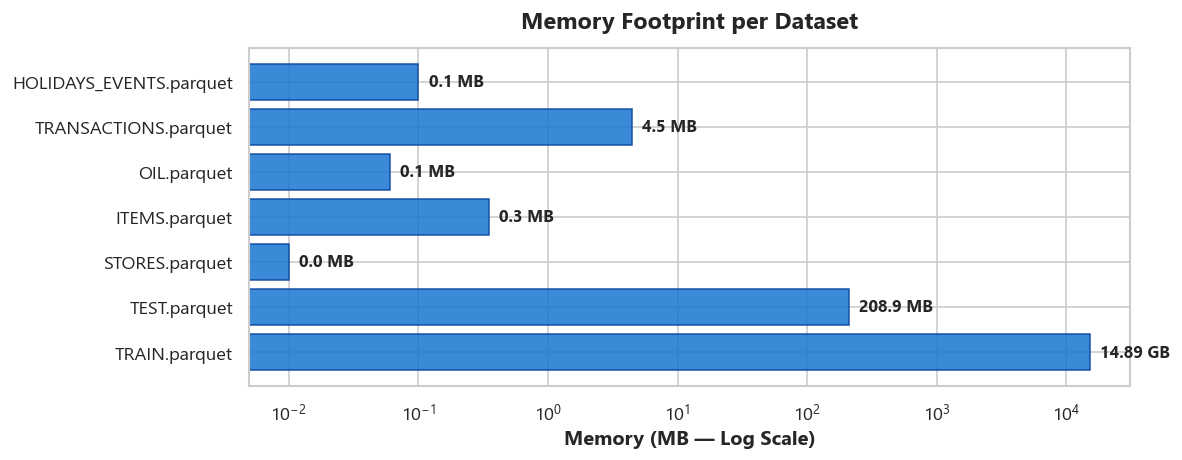

In [7]:
# Memory Footprint Visualization
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_summary['Dataset'], df_summary['Memory (MB)'],
               color='#1976d2', edgecolor='#0d47a1', alpha=0.85)
ax.set_xscale('log')
ax.set_xlabel('Memory (MB — Log Scale)', fontweight='bold')
ax.set_title('Memory Footprint per Dataset', fontsize=14, fontweight='bold', pad=12)

for bar in bars:
    w = bar.get_width()
    lbl = f'{w:,.1f} MB' if w < 1024 else f'{w/1024:,.2f} GB'
    ax.text(w * 1.2, bar.get_y() + bar.get_height()/2, lbl,
            ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
save_fig(fig, '01_memory_footprint.png')


## 5️⃣ Statistical Summary

Examine the **central tendency, spread, and skewness** of every numeric column  
across all datasets. This reveals potential scaling issues and anomalies.


In [11]:
for name, df in datasets.items():
    print('═' * 70)
    print(f'📈 {name.upper()}')
    print('═' * 70)

    num = df.select_dtypes(include=[np.number])
    if not num.empty:
        stats = num.describe().T
        stats['skewness'] = num.skew()
        display(
            stats.style
            .format('{:,.4f}')
            .background_gradient(subset=['mean', 'std'], cmap='Purples')
            .set_caption(f'Numeric features — {name}')
        )
    else:
        print('  No numeric columns.')

    cat = df.select_dtypes(include=['object', 'category', 'datetime64']).columns
    if len(cat) > 0:
        print(f'\n  Categorical / Date columns ({len(cat)}):')
        display(df[cat].astype(str).describe().T)
    print()


══════════════════════════════════════════════════════════════════════
📈 TRAIN
══════════════════════════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max,skewness
id,"125,497,040.0000","62,748,519.5000","36,227,875.0576",0.0000,"31,374,259.7500","62,748,519.5000","94,122,779.2500","125,497,039.0000",-0.0000
store_nbr,"125,497,040.0000",27.4646,16.3305,1.0000,12.0000,28.0000,43.0000,54.0000,-0.0742
item_nbr,"125,497,040.0000","972,769.1527","520,533.5986","96,995.0000","522,383.0000","959,500.0000","1,354,380.0000","2,127,114.0000",0.2193
unit_sales,"125,497,040.0000",8.5549,23.6052,"-15,372.0000",2.0000,4.0000,9.0000,"89,440.0000",582.2246



  Categorical / Date columns (2):


,count,unique,top,freq
date,125497040,1684,2017-07-01,118194
onpromotion,125497040,3,False,96028767



══════════════════════════════════════════════════════════════════════
📈 TEST
══════════════════════════════════════════════════════════════════════


...

,count,mean,std,min,25%,50%,75%,max,skewness
store_nbr,"83,488.0000",26.9392,15.6082,1.0000,13.0000,27.0000,40.0000,54.0000,0.0035
transactions,"83,488.0000","1,694.6022",963.2866,5.0000,"1,046.0000","1,393.0000","2,079.0000","8,359.0000",1.5184



  Categorical / Date columns (1):


,count,unique,top,freq
date,83488,1682,2017-07-29,54



══════════════════════════════════════════════════════════════════════
📈 HOLIDAYS_EVENTS
══════════════════════════════════════════════════════════════════════
  No numeric columns.

  Categorical / Date columns (5):


,count,unique,top,freq
date,350,312,2014-06-25,4
type,350,6,Holiday,221
locale,350,3,National,174
locale_name,350,24,Ecuador,174
description,350,103,Carnaval,10


## 6️⃣ Missing Values Audit

Identify **every null value** across all datasets.  
Missing data strategy will be implemented in Notebook 03 (Preprocessing).


In [12]:
# Build missing values report
report = []
for name, df in datasets.items():
    for col in df.columns:
        cnt = df[col].isnull().sum()
        pct = cnt / len(df) * 100
        report.append({
            'Dataset': f'{name}.parquet', 'Column': col,
            'Null Count': cnt, 'Null %': round(pct, 4),
            'Dtype': str(df[col].dtype),
            'Status': '⚠️ Missing' if cnt > 0 else '✅ Clean'
        })

df_miss = pd.DataFrame(report)
df_missing = df_miss[df_miss['Null Count'] > 0].reset_index(drop=True)

if df_missing.empty:
    print('✅ All datasets are 100% complete — no missing values!')
else:
    display(
        df_missing.style
        .format({'Null Count': '{:,}', 'Null %': '{:.2f}%'})
        .bar(subset=['Null %'], color='#ef5350', vmin=0)
        .set_caption('⚠️ Columns with Missing Values')
    )


,Dataset,Column,Null Count,Null %,Dtype,Status
0,train.parquet,onpromotion,"21,657,651",17.26%,object,⚠️ Missing
1,oil.parquet,dcoilwtico,43,3.53%,float64,⚠️ Missing


💾 Saved → 02_missing_values.png


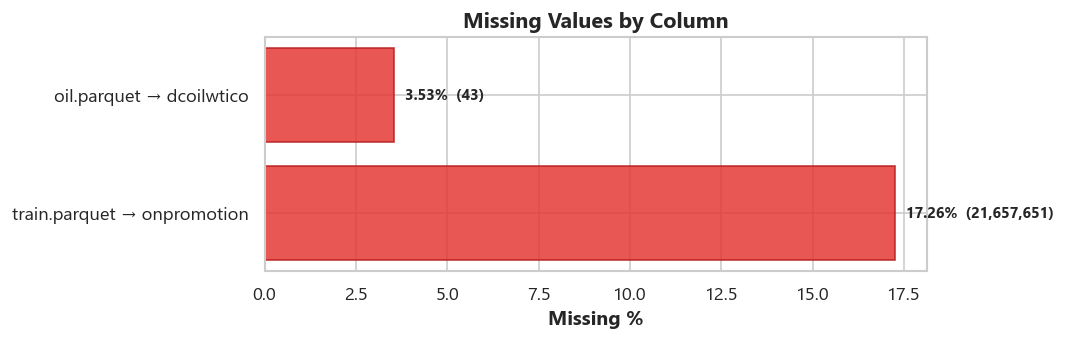

In [14]:
# Missing Values Bar Chart
if not df_missing.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, len(df_missing) * 0.5)))
    labels = df_missing['Dataset'] + ' → ' + df_missing['Column']
    ax.barh(labels, df_missing['Null %'], color='#e53935', alpha=0.85, edgecolor='#b71c1c')
    ax.set_xlabel('Missing %', fontweight='bold')
    ax.set_title('Missing Values by Column', fontweight='bold', fontsize=13)
    for i, v in enumerate(df_missing['Null %']):
        ax.text(v + 0.3, i, f'{v:.2f}%  ({df_missing.iloc[i]["Null Count"]:,})',
                va='center', fontweight='bold', fontsize=9)
    plt.tight_layout()
    save_fig(fig, '02_missing_values.png')
else:
    print('ℹ️ No missing values chart needed.')


## 7️⃣ Target Variable Analysis

`unit_sales` is the **prediction target**. Understanding its distribution is critical for:
- Choosing the right **loss function** (RMSLE vs RMSE)
- Deciding on **target transformation** (log1p)
- Identifying **returns** (negative sales) and **zero-inflation**


In [17]:
# Target Variable KPI Cards
sales = df_train['unit_sales']
total  = len(sales)
pos    = (sales > 0).sum()
zero   = (sales == 0).sum()
neg    = (sales < 0).sum()

display(kpi('Total Records', f'{total:,}', 'Full Training Set', '#1565c0'))
display(kpi('Positive (> 0)', f'{pos:,}', f'{pos/total*100:.2f}%', '#2e7d32'))
display(kpi('Zero Sales', f'{zero:,}', f'{zero/total*100:.2f}%', '#f57c00'))
display(kpi('Returns (< 0)', f'{neg:,}', f'{neg/total*100:.2f}%', '#c62828'))


C:\Users\OKCode\AppData\Local\Temp\ipykernel_32368\3787321905.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Segoe UI.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\OKCode\AppData\Local\Temp\ipykernel_32368\2402641359.py:62: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Segoe UI.
  fig.savefig(


💾 Figure saved → F:\NTI\Demand Forecasting System Backup\output\01_data_understanding\03_target_dashboard.png


c:\Users\OKCode\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


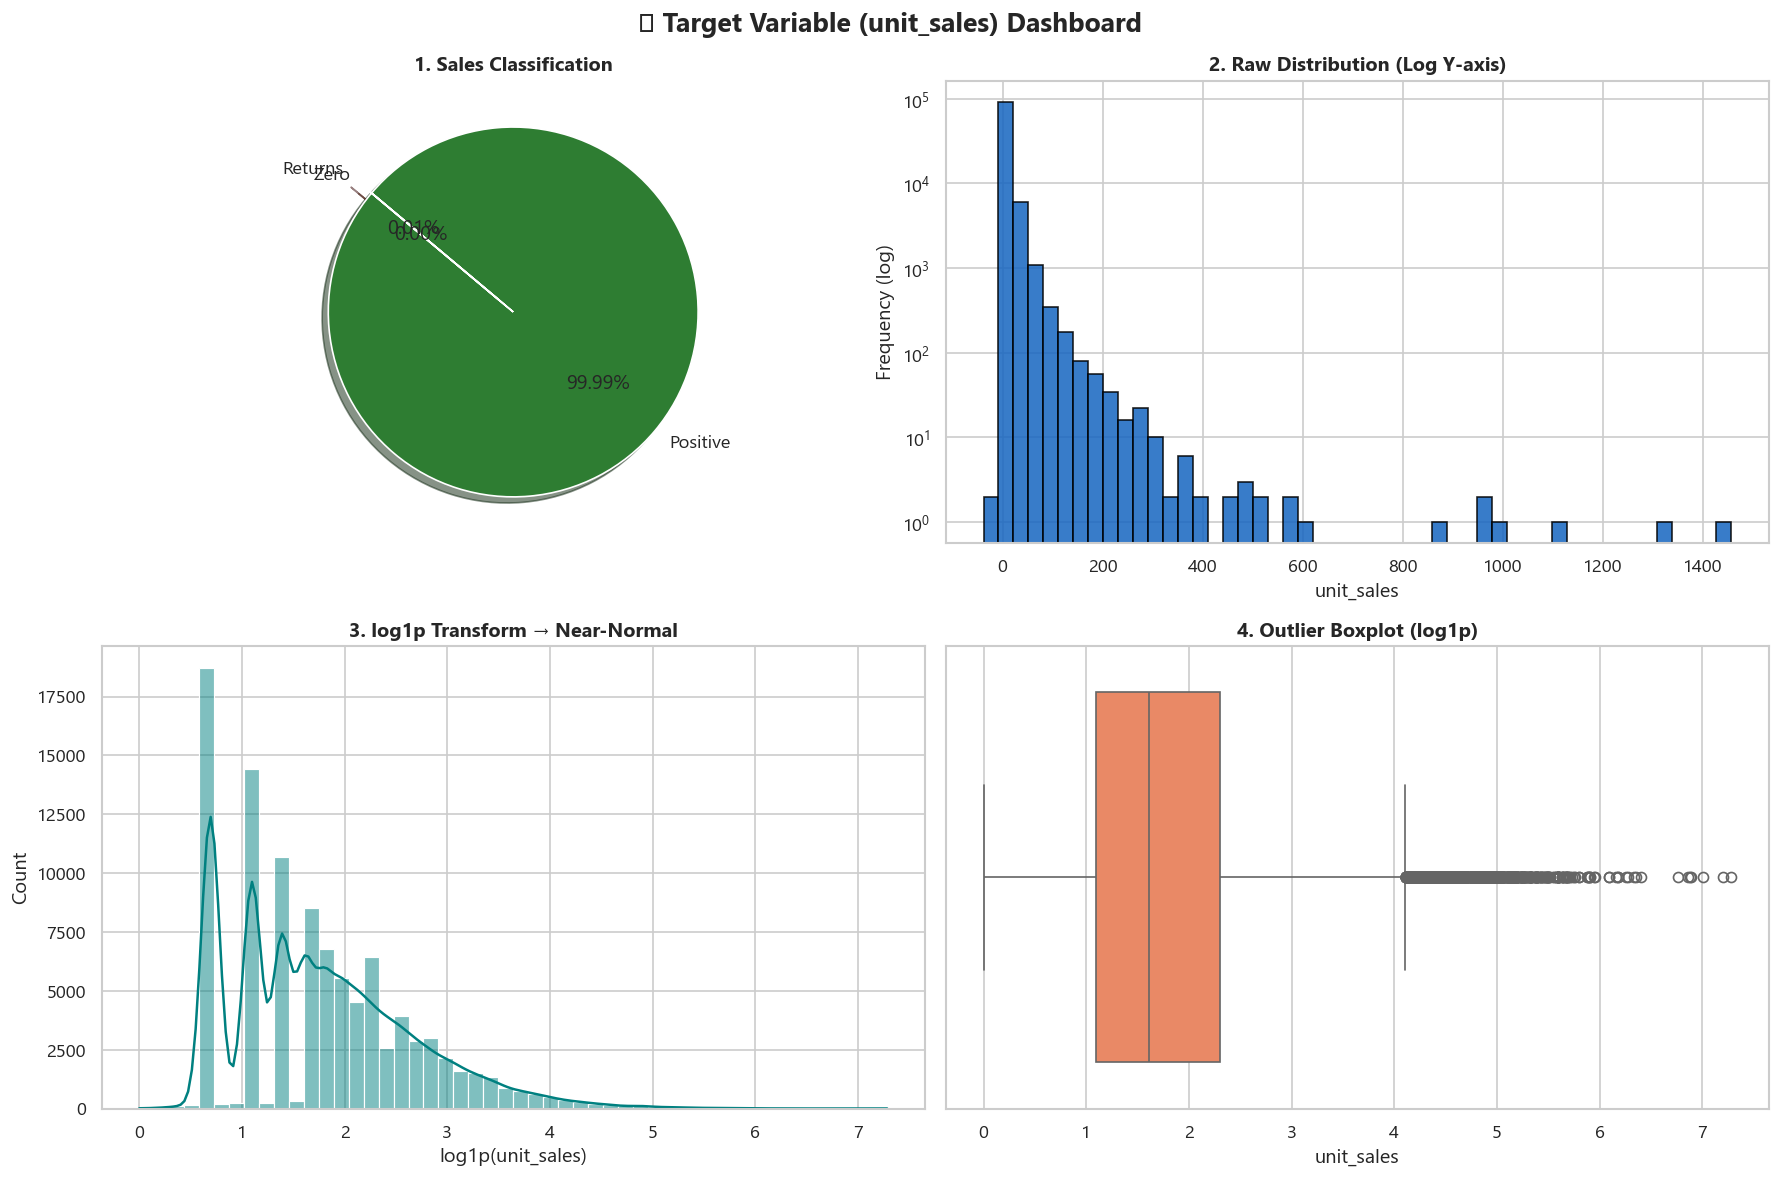

In [18]:
# Target Variable 4-Panel Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🎯 Target Variable (unit_sales) Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

sample = sales.sample(n=min(100_000, total), random_state=config.RANDOM_SEED)

# 1 — Classification pie
axes[0,0].pie([pos, zero, neg],
    labels=['Positive', 'Zero', 'Returns'],
    colors=['#2e7d32', '#f57c00', '#c62828'],
    autopct='%1.2f%%', startangle=140,
    explode=(0, 0.05, 0.1), shadow=True)
axes[0,0].set_title('1. Sales Classification', fontweight='bold')

# 2 — Raw distribution (log-y)
axes[0,1].hist(sample, bins=50, color='#1565c0', edgecolor='black', log=True, alpha=0.85)
axes[0,1].set_title('2. Raw Distribution (Log Y-axis)', fontweight='bold')
axes[0,1].set_xlabel('unit_sales'); axes[0,1].set_ylabel('Frequency (log)')

# 3 — log1p distribution
log_s = np.log1p(np.maximum(0, sample))
sns.histplot(log_s, bins=50, kde=True, color='teal', ax=axes[1,0])
axes[1,0].set_title('3. log1p Transform → Near-Normal', fontweight='bold')
axes[1,0].set_xlabel('log1p(unit_sales)')

# 4 — Outlier boxplot
sns.boxplot(x=log_s, color='coral', ax=axes[1,1])
axes[1,1].set_title('4. Outlier Boxplot (log1p)', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, '03_target_dashboard.png')


## 8️⃣ Entity Cardinality & Distributions

How many **unique entities** exist in each dataset?  
High cardinality columns need special encoding strategies.


In [19]:
# Entity Cardinality KPI Cards
display(kpi('Stores', f"{df_stores['store_nbr'].nunique()}",
            f"{df_stores['city'].nunique()} cities · {df_stores['state'].nunique()} states", '#00897b'))
display(kpi('Items', f"{df_items['item_nbr'].nunique():,}",
            f"{df_items['family'].nunique()} families · {df_items['class'].nunique()} classes", '#8e24aa'))
display(kpi('Oil Records', f"{len(df_oil):,}",
            f"{df_oil['dcoilwtico'].notna().sum()} non-null prices", '#e65100'))
display(kpi('Holidays', f"{len(df_holidays)}",
            f"{df_holidays['type'].nunique()} types", '#d81b60'))


💾 Figure saved → F:\NTI\Demand Forecasting System Backup\output\01_data_understanding\04_cardinality.png


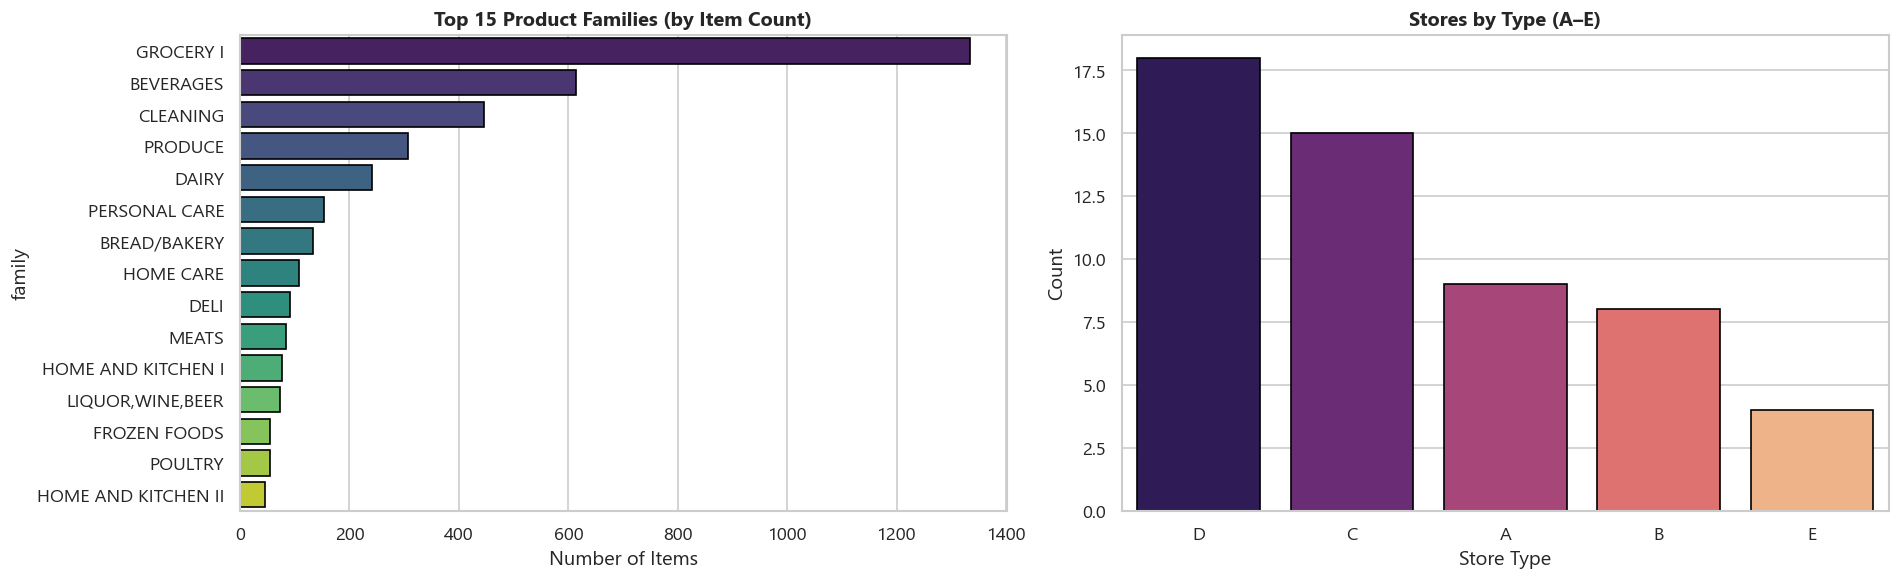

In [20]:
# Distribution Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Product families by item count
top_fam = df_items['family'].value_counts().head(15)
sns.barplot(x=top_fam.values, y=top_fam.index, hue=top_fam.index,
            palette='viridis', ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Top 15 Product Families (by Item Count)', fontweight='bold')
axes[0].set_xlabel('Number of Items')

# Store count by type
st = df_stores['type'].value_counts()
sns.barplot(x=st.index, y=st.values, hue=st.index,
            palette='magma', ax=axes[1], edgecolor='black', legend=False)
axes[1].set_title('Stores by Type (A–E)', fontweight='bold')
axes[1].set_xlabel('Store Type'); axes[1].set_ylabel('Count')

plt.tight_layout()
save_fig(fig, '04_cardinality.png')


## 9️⃣ Dataset Timeline Alignment

Do all date-based datasets **overlap** correctly?  
Gaps or misalignment will cause issues during merging.


💾 Figure saved → F:\NTI\Demand Forecasting System Backup\output\01_data_understanding\05_timeline.png


C:\Users\OKCode\AppData\Local\Temp\ipykernel_32368\4032614909.py:19: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Segoe UI.
  plt.tight_layout()
C:\Users\OKCode\AppData\Local\Temp\ipykernel_32368\2402641359.py:62: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Segoe UI.
  fig.savefig(
c:\Users\OKCode\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


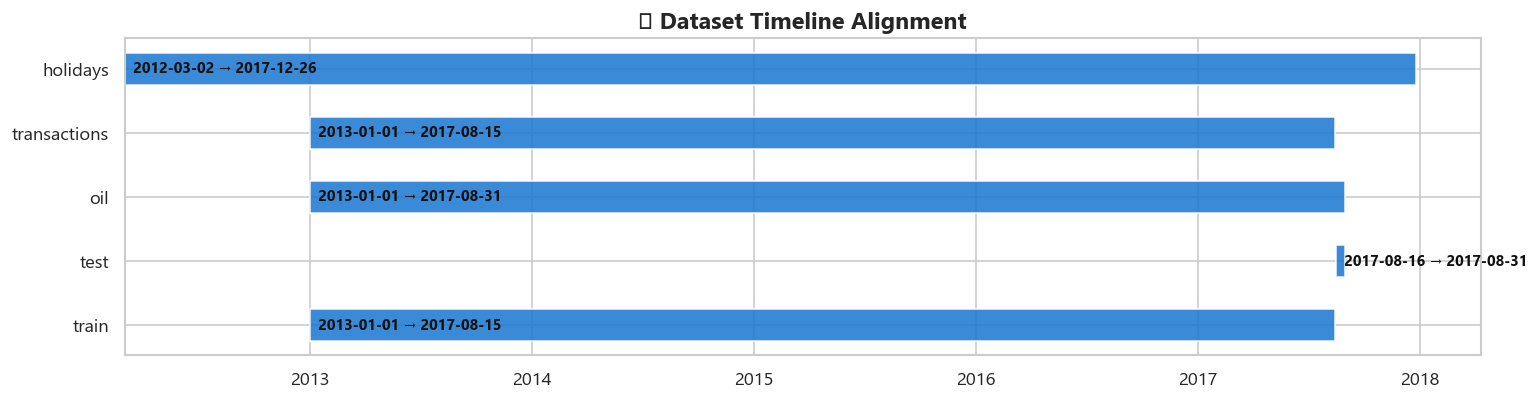

In [ ]:
# Timeline Gantt Chart
spans = [
    ('train',        pd.to_datetime(df_train['date'].min()),    pd.to_datetime(df_train['date'].max())),
    ('test',         pd.to_datetime(df_test['date'].min()),     pd.to_datetime(df_test['date'].max())),
    ('oil',          pd.to_datetime(df_oil['date'].min()),      pd.to_datetime(df_oil['date'].max())),
    ('transactions', pd.to_datetime(df_trans['date'].min()),    pd.to_datetime(df_trans['date'].max())),
    ('holidays',     pd.to_datetime(df_holidays['date'].min()), pd.to_datetime(df_holidays['date'].max())),
]

fig, ax = plt.subplots(figsize=(13, 3.5))
for i, (name, start, end) in enumerate(spans):
    ax.barh(name, (end - start).days, left=start,
            color='#1976d2', alpha=0.85, height=0.5)
    ax.text(start, i,
            f'  {start:%Y-%m-%d} → {end:%Y-%m-%d}',
            va='center', fontweight='bold', fontsize=9, color='#111')

ax.set_title('Dataset Timeline Alignment', fontweight='bold', fontsize=14)
plt.tight_layout()
save_fig(fig, '05_timeline.png')


---

## 📝 Data Understanding Summary

| # | Finding | Action |
|---|---------|--------|
| 1 | `train.parquet` has **125M+ rows** (~15 GB in RAM) | Use memory-efficient aggregation in EDA |
| 2 | `unit_sales` is heavily **right-skewed** with **zero-inflation** | Apply `log1p` transform for modeling |
| 3 | `oil.dcoilwtico` has **~7% missing** values | Forward-fill in preprocessing |
| 4 | `onpromotion` has missing values in early years | Fill with `False` |
| 5 | All datasets have **overlapping timelines** (2013–2017) | Safe to merge on `date` |
| 6 | 33 product families, 54 stores, 17 clusters | Rich categorical features |

---

## ✅ Checkpoint

- [x] All 7 datasets loaded and profiled
- [x] Memory footprint documented
- [x] Missing values identified
- [x] Target variable analyzed
- [x] Entity cardinality mapped
- [x] Timeline alignment verified
- [x] All figures saved to `output/01_data_understanding/`

**➡️ Next:** Open `02_eda.ipynb` for deep exploratory analysis
